In [23]:
!pip install scikit-fuzzy

Kecepatan kipas: 77.70%


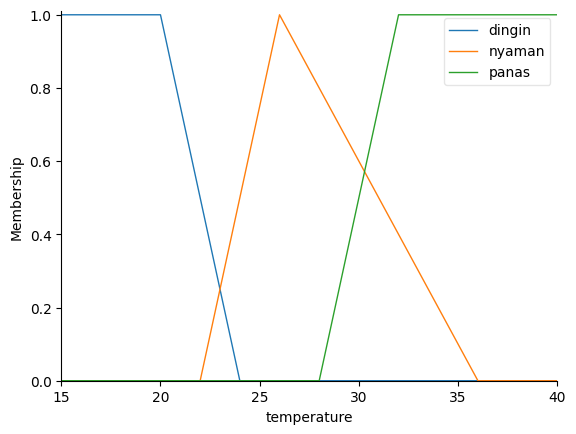

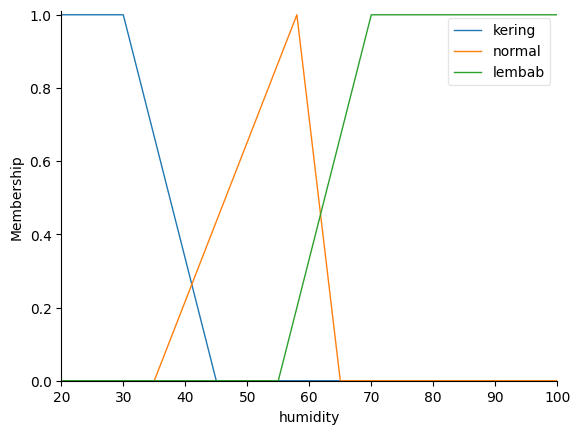

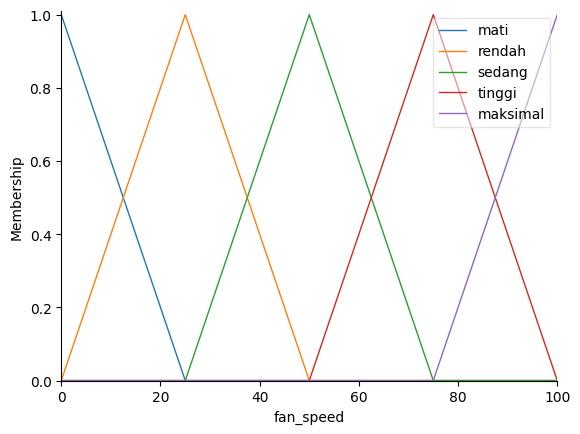

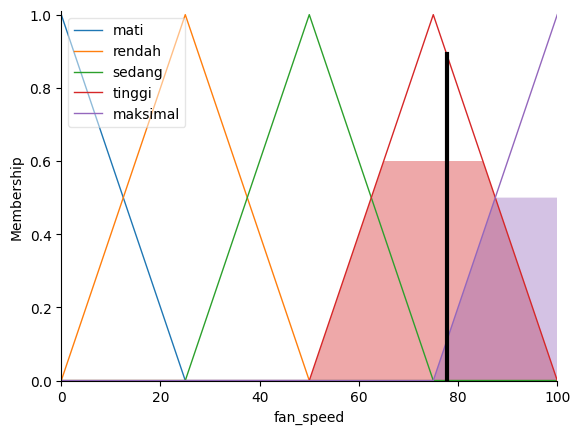

In [27]:
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl
import matplotlib.pyplot as plt


temperature = ctrl.Antecedent(np.arange(15, 41, 1), 'temperature')
humidity = ctrl.Antecedent(np.arange(20, 101, 1), 'humidity')


fan_speed = ctrl.Consequent(np.arange(0, 101, 1), 'fan_speed')


temperature['dingin'] = fuzz.trapmf(temperature.universe, [15, 15, 20, 24])
temperature['nyaman'] = fuzz.trimf(temperature.universe, [22, 26, 36])
temperature['panas'] = fuzz.trapmf(temperature.universe, [28, 32, 40, 40])


humidity['kering'] = fuzz.trapmf(humidity.universe, [20, 20, 30, 45])
humidity['normal'] = fuzz.trimf(humidity.universe, [35, 58, 65])
humidity['lembab'] = fuzz.trapmf(humidity.universe, [55, 70, 100, 100])


fan_speed['mati'] = fuzz.trimf(fan_speed.universe, [0, 0, 25])
fan_speed['rendah'] = fuzz.trimf(fan_speed.universe, [0, 25, 50])
fan_speed['sedang'] = fuzz.trimf(fan_speed.universe, [25, 50, 75])
fan_speed['tinggi'] = fuzz.trimf(fan_speed.universe, [50, 75, 100])
fan_speed['maksimal'] = fuzz.trimf(fan_speed.universe, [75, 100, 100])


temperature.view()
humidity.view()
fan_speed.view()

# Define fuzzy rules (aturan lama)
rule1 = ctrl.Rule(temperature['dingin'] & humidity['kering'], fan_speed['mati'])
rule2 = ctrl.Rule(temperature['dingin'] & humidity['normal'], fan_speed['mati'])
rule3 = ctrl.Rule(temperature['dingin'] & humidity['lembab'], fan_speed['rendah'])
rule4 = ctrl.Rule(temperature['nyaman'] & humidity['kering'], fan_speed['rendah'])
rule5 = ctrl.Rule(temperature['nyaman'] & humidity['normal'], fan_speed['sedang'])
rule6 = ctrl.Rule(temperature['nyaman'] & humidity['lembab'], fan_speed['tinggi'])
rule7 = ctrl.Rule(temperature['panas'] & humidity['kering'], fan_speed['tinggi'])
rule8 = ctrl.Rule(temperature['panas'] & humidity['normal'], fan_speed['tinggi'])
rule9 = ctrl.Rule(temperature['panas'] & humidity['lembab'], fan_speed['maksimal'])

#  Tambahan aturan baru
rule10 = ctrl.Rule(temperature['nyaman'] & humidity['lembab'], fan_speed['tinggi'])
rule11 = ctrl.Rule(temperature['dingin'] & humidity['kering'], fan_speed['mati'])
rule12 = ctrl.Rule(temperature['nyaman'] & humidity['normal'], fan_speed['sedang'])


fan_ctrl = ctrl.ControlSystem([rule1, rule2, rule3, rule4, rule5, rule6,
                               rule7, rule8, rule9, rule10, rule11, rule12])
fan_sim = ctrl.ControlSystemSimulation(fan_ctrl)


fan_sim.input['temperature'] = 30
fan_sim.input['humidity'] = 70
fan_sim.compute()

print(f"Kecepatan kipas: {fan_sim.output['fan_speed']:.2f}%")
fan_speed.view(sim=fan_sim)
plt.show()


**Penjelasan**

 Mengapa Suhu 28°C Masuk Dua Kategori
temperature['nyaman'] itu karena dimulai dari 22 hingga 36°C dengan puncak 26°C → di 28°C masih punya nilai keanggotaan.

temperature['panas'] dimulai dari 28°C → jadi 28°C adalah titik awal dari "panas".

Maka, 28°C dianggap sebagian nyaman, sebagian panas.

